In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [2]:
# https://www.kaggle.com/datasets/anmolkumar/health-insurance-cross-sell-prediction/data?select=train.csv

In [3]:
df = pd.read_csv("train.csv")  #train df
test_df = pd.read_csv("test.csv")

In [4]:
df

,id,Gender,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage,Response
0,1,Male,44,1,28.0,0,> 2 Years,Yes,40454.0,26.0,217,1
1,2,Male,76,1,3.0,0,1-2 Year,No,33536.0,26.0,183,0
2,3,Male,47,1,28.0,0,> 2 Years,Yes,38294.0,26.0,27,1
3,4,Male,21,1,11.0,1,< 1 Year,No,28619.0,152.0,203,0
4,5,Female,29,1,41.0,1,< 1 Year,No,27496.0,152.0,39,0
...,...,...,...,...,...,...,...,...,...,...,...,...
381104,381105,Male,74,1,26.0,1,1-2 Year,No,30170.0,26.0,88,0
381105,381106,Male,30,1,37.0,1,< 1 Year,No,40016.0,152.0,131,0
381106,381107,Male,21,1,30.0,1,< 1 Year,No,35118.0,160.0,161,0
381107,381108,Female,68,1,14.0,0,> 2 Years,Yes,44617.0,124.0,74,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 381109 entries, 0 to 381108
Data columns (total 12 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   id                    381109 non-null  int64  
 1   Gender                381109 non-null  object 
 2   Age                   381109 non-null  int64  
 3   Driving_License       381109 non-null  int64  
 4   Region_Code           381109 non-null  float64
 5   Previously_Insured    381109 non-null  int64  
 6   Vehicle_Age           381109 non-null  object 
 7   Vehicle_Damage        381109 non-null  object 
 8   Annual_Premium        381109 non-null  float64
 9   Policy_Sales_Channel  381109 non-null  float64
 10  Vintage               381109 non-null  int64  
 11  Response              381109 non-null  int64  
dtypes: float64(3), int64(6), object(3)
memory usage: 34.9+ MB


In [6]:
df.drop(columns="id", axis=1, inplace=True)

In [7]:
df["Gender"].unique()

array(['Male', 'Female'], dtype=object)

In [8]:
gender_map = {
    'Male': 1,
    'Female': 0
}

df["Gender"] = df["Gender"].map(gender_map)

In [9]:
df["Gender"]

0         1
1         1
2         1
3         1
4         0
         ..
381104    1
381105    1
381106    1
381107    0
381108    1
Name: Gender, Length: 381109, dtype: int64

In [10]:
df["Age"].unique()

array([44, 76, 47, 21, 29, 24, 23, 56, 32, 41, 71, 37, 25, 42, 60, 65, 49,
       34, 51, 26, 57, 79, 48, 45, 72, 30, 54, 27, 38, 22, 78, 20, 39, 62,
       58, 59, 63, 50, 67, 77, 28, 69, 52, 31, 33, 43, 36, 53, 70, 46, 55,
       40, 61, 75, 64, 35, 66, 68, 74, 73, 84, 83, 81, 80, 82, 85])

In [11]:
df["Driving_License"].unique()

array([1, 0])

In [12]:
df["Region_Code"].unique()

array([28.,  3., 11., 41., 33.,  6., 35., 50., 15., 45.,  8., 36., 30.,
       26., 16., 47., 48., 19., 39., 23., 37.,  5., 17.,  2.,  7., 29.,
       46., 27., 25., 13., 18., 20., 49., 22., 44.,  0.,  9., 31., 12.,
       34., 21., 10., 14., 38., 24., 40., 43., 32.,  4., 51., 42.,  1.,
       52.])

In [13]:
df["Previously_Insured"].unique()

array([0, 1])

In [14]:
df["Vehicle_Age"].unique()

array(['> 2 Years', '1-2 Year', '< 1 Year'], dtype=object)

In [15]:
vehicle_age_map = {
    '< 1 Year': 0,
    '1-2 Year': 1,
    '> 2 Years': 2
}

In [16]:
df['Vehicle_Age'] = df['Vehicle_Age'].map(vehicle_age_map)
test_df['Vehicle_Age'] = test_df['Vehicle_Age'].map(vehicle_age_map)

In [17]:
df["Vehicle_Damage"].unique()

array(['Yes', 'No'], dtype=object)

In [18]:
vehicle_damage_map = {
    'Yes': 1,
    'No': 0
}

In [19]:
df['Vehicle_Damage'] = df['Vehicle_Damage'].map(vehicle_damage_map)
test_df['Vehicle_Damage'] = test_df['Vehicle_Damage'].map(vehicle_damage_map)

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 381109 entries, 0 to 381108
Data columns (total 11 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Gender                381109 non-null  int64  
 1   Age                   381109 non-null  int64  
 2   Driving_License       381109 non-null  int64  
 3   Region_Code           381109 non-null  float64
 4   Previously_Insured    381109 non-null  int64  
 5   Vehicle_Age           381109 non-null  int64  
 6   Vehicle_Damage        381109 non-null  int64  
 7   Annual_Premium        381109 non-null  float64
 8   Policy_Sales_Channel  381109 non-null  float64
 9   Vintage               381109 non-null  int64  
 10  Response              381109 non-null  int64  
dtypes: float64(3), int64(8)
memory usage: 32.0 MB


In [21]:
df.tail()

,Gender,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage,Response
381104,1,74,1,26.0,1,1,0,30170.0,26.0,88,0
381105,1,30,1,37.0,1,0,0,40016.0,152.0,131,0
381106,1,21,1,30.0,1,0,0,35118.0,160.0,161,0
381107,0,68,1,14.0,0,2,1,44617.0,124.0,74,0
381108,1,46,1,29.0,0,1,0,41777.0,26.0,237,0


In [22]:
df.describe()

,Gender,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage,Response
count,381109.000000,381109.000000,381109.000000,381109.000000,381109.000000,381109.000000,381109.000000,381109.000000,381109.000000,381109.000000,381109.000000
mean,0.540761,38.822584,0.997869,26.388807,0.458210,0.609616,0.504877,30564.389581,112.034295,154.347397,0.122563
std,0.498336,15.511611,0.046110,13.229888,0.498251,0.567439,0.499977,17213.155057,54.203995,83.671304,0.327936
min,0.000000,20.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2630.000000,1.000000,10.000000,0.000000
25%,0.000000,25.000000,1.000000,15.000000,0.000000,0.000000,0.000000,24405.000000,29.000000,82.000000,0.000000
50%,1.000000,36.000000,1.000000,28.000000,0.000000,1.000000,1.000000,31669.000000,133.000000,154.000000,0.000000
75%,1.000000,49.000000,1.000000,35.000000,1.000000,1.000000,1.000000,39400.000000,152.000000,227.000000,0.000000
max,1.000000,85.000000,1.000000,52.000000,1.000000,2.000000,1.000000,540165.000000,163.000000,299.000000,1.000000


In [23]:
df.corr(numeric_only=True)

,Gender,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage,Response
Gender,1.000000,0.145545,-0.018374,0.000604,-0.081932,0.160427,0.091606,0.003673,-0.111159,-0.002517,0.052440
Age,0.145545,1.000000,-0.079782,0.042574,-0.254682,0.765790,0.267534,0.067507,-0.577826,-0.001264,0.111147
Driving_License,-0.018374,-0.079782,1.000000,-0.001081,0.014969,-0.037306,-0.016622,-0.011906,0.043731,-0.000848,0.010155
Region_Code,0.000604,0.042574,-0.001081,1.000000,-0.024659,0.043778,0.028235,-0.010588,-0.042420,-0.002750,0.010570
Previously_Insured,-0.081932,-0.254682,0.014969,-0.024659,1.000000,-0.380873,-0.824143,0.004269,0.219381,0.002537,-0.341170
Vehicle_Age,0.160427,0.765790,-0.037306,0.043778,-0.380873,1.000000,0.396873,0.041580,-0.550663,-0.001892,0.221874
Vehicle_Damage,0.091606,0.267534,-0.016622,0.028235,-0.824143,0.396873,1.000000,0.009349,-0.224377,-0.002064,0.354400
Annual_Premium,0.003673,0.067507,-0.011906,-0.010588,0.004269,0.041580,0.009349,1.000000,-0.113247,-0.000608,0.022575
Policy_Sales_Channel,-0.111159,-0.577826,0.043731,-0.042420,0.219381,-0.550663,-0.224377,-0.113247,1.000000,0.000002,-0.139042
Vintage,-0.002517,-0.001264,-0.000848,-0.002750,0.002537,-0.001892,-0.002064,-0.000608,0.000002,1.000000,-0.001050


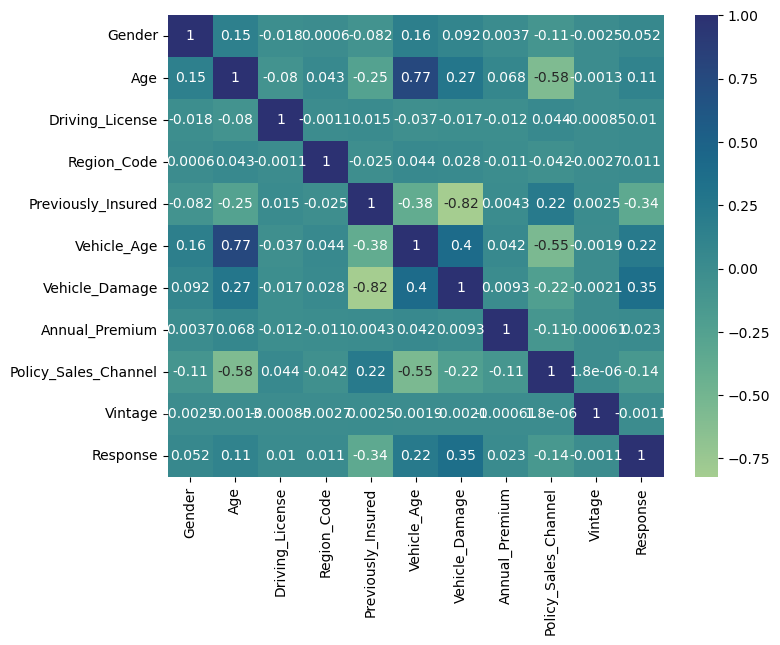

In [24]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), cmap="crest", annot=True)
plt.show()

In [25]:
# -0.34 -> Previously_Insured
# 0.35 -> Vehicle_Damage

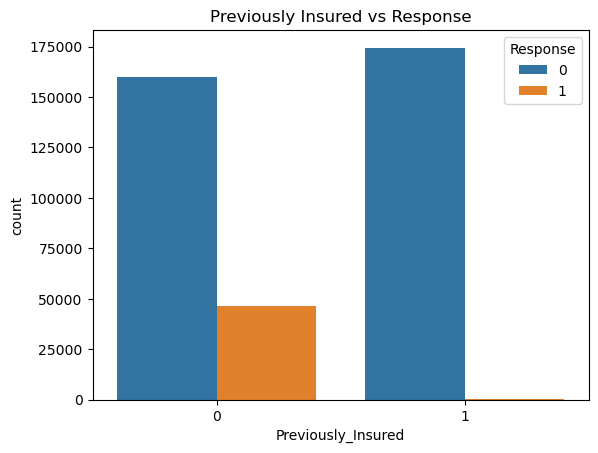

In [26]:
sns.countplot(x="Previously_Insured", hue="Response", data=df)
plt.title("Previously Insured vs Response")
plt.show()

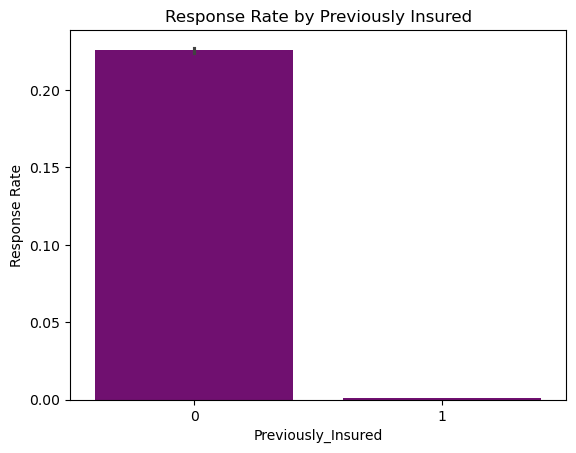

In [27]:
sns.barplot(data=df,x="Previously_Insured",y="Response", color="purple")
plt.title("Response Rate by Previously Insured")
plt.ylabel("Response Rate")
plt.show()

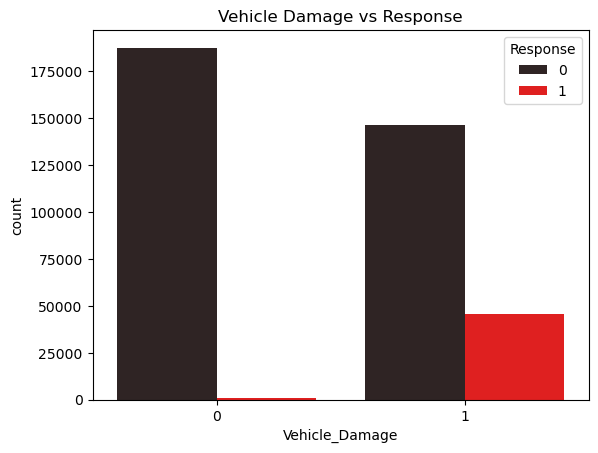

In [28]:
sns.countplot(x="Vehicle_Damage", hue="Response", data=df, palette="dark:red")
plt.title("Vehicle Damage vs Response")
plt.show()

<Figure size 600x600 with 0 Axes>

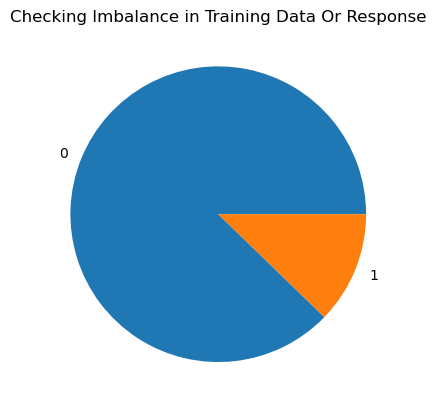

In [29]:
response_data = df['Response'].value_counts()
plt.figure(figsize=(6,6))
fig, ax = plt.subplots()
ax.pie(response_data, labels = [0,1])
ax.set_title('Checking Imbalance in Training Data Or Response')
plt.show()

In [30]:
X = df.drop(columns="Response")
y = df["Response"]

In [31]:
from sklearn.model_selection import train_test_split
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [32]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [33]:
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

In [34]:
from imblearn.over_sampling import SMOTE
smote = SMOTE()

In [35]:
X_smote, y_smote = smote.fit_resample(X_train_scaled,y_train)

In [36]:
y_train.value_counts()

Response
0    267519
1     37368
Name: count, dtype: int64

In [37]:
y_smote.value_counts()

Response
0    267519
1    267519
Name: count, dtype: int64

In [38]:
from sklearn import metrics
from sklearn.metrics import *
from sklearn.linear_model import LogisticRegression

In [39]:
def model_prediction(model):
    model.fit(X_train_scaled,y_train)
    x_train_pred = model.predict(X_train_scaled)
    x_val_pred = model.predict(X_val_scaled)
    y_test_prob = model.predict_proba(X_val_scaled)[:, 1]

    a = accuracy_score(y_train,x_train_pred)*100
    b = accuracy_score(y_val,x_val_pred)*100
    c = precision_score(y_val,x_val_pred)
    d = recall_score(y_val,x_val_pred)
    e = roc_auc_score(y_val, y_test_prob)
    print(f"Accuracy_Score of {model} model on Training Data is:",a)
    print(f"Accuracy_Score of {model} model on Testing Data is:",b)
    print(f"Precision Score of {model} model is:",c)
    print(f"Recall Score of {model} model is:",d)
    print(f"AUC Score of {model} model is:", e)
    print(classification_report(y_val, x_val_pred))
    print("\n------------------------------------------------------------------------")
    print(f"Confusion Matrix of {model} model is:")
    cm = confusion_matrix(y_val,x_val_pred)
    plt.figure(figsize=(8,4))
    sns.heatmap(cm,annot=True,fmt="g",cmap="Greens")
    plt.show()

In [43]:
def compare_models(
    X_train_smote,
    y_train_smote,
    X_val_scaled,
    y_val,
    threshold=0.5
):
    models = {
        "LogisticRegression": LogisticRegression(max_iter=1000),
        "DecisionTree": DecisionTreeClassifier(
            max_depth=8,
            min_samples_leaf=50,
            class_weight="balanced",
            random_state=42
        ),
        "RandomForest": RandomForestClassifier(
            n_estimators=200,
            max_depth=10,
            class_weight="balanced",
            n_jobs=-1,
            random_state=42
        ),
        "SVC": SVC(
            probability=True,
            class_weight="balanced",
            random_state=42
        )
    }

    results = []

    for name, model in models.items():
        # Train
        model.fit(X_train_smote, y_train_smote)

        # Predict proba
        y_proba = model.predict_proba(X_val_scaled)[:, 1]
        y_pred  = (y_proba >= threshold).astype(int)

        results.append({
            "Model": name,
            "Accuracy": accuracy_score(y_val, y_pred),
            "Precision_1": precision_score(y_val, y_pred),
            "Recall_1": recall_score(y_val, y_pred),
            "F1_1": f1_score(y_val, y_pred),
            "ROC_AUC": roc_auc_score(y_val, y_proba)
        })

    return pd.DataFrame(results).sort_values(
        by="F1_1", ascending=False
    )


              precision    recall  f1-score   support

           0       0.91      0.91      0.91     66880
           1       0.33      0.33      0.33      9342

    accuracy                           0.84     76222
   macro avg       0.62      0.62      0.62     76222
weighted avg       0.84      0.84      0.84     76222

0.8376452992574323


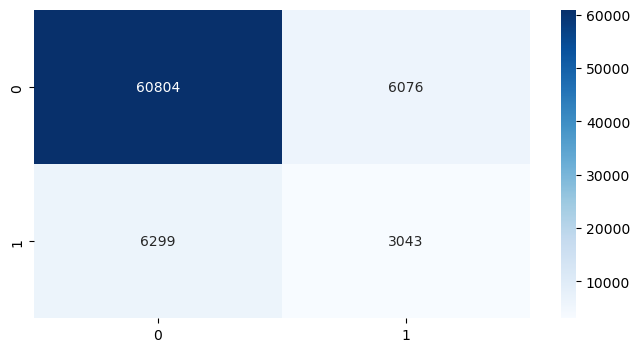

In [45]:
rfc = RandomForestClassifier()
rfc.fit(X_smote, y_smote)
y_pred = rfc.predict(X_val_scaled)
print(classification_report(y_val,y_pred))
print(accuracy_score(y_val,y_pred))

cm = confusion_matrix(y_val,y_pred)
plt.figure(figsize=(8,4))
sns.heatmap(cm,annot=True,fmt="g",cmap="Blues")
plt.show()